In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import random
from collections import defaultdict
import numpy as np
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure
from dimensionality_manuscript.simulations import process, StimFullConfig
from dimensionality_manuscript.schematics.subspace import StimNuisance2D, plot_stim_nuisance_2D

plt.rcParams["font.size"] = 14

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


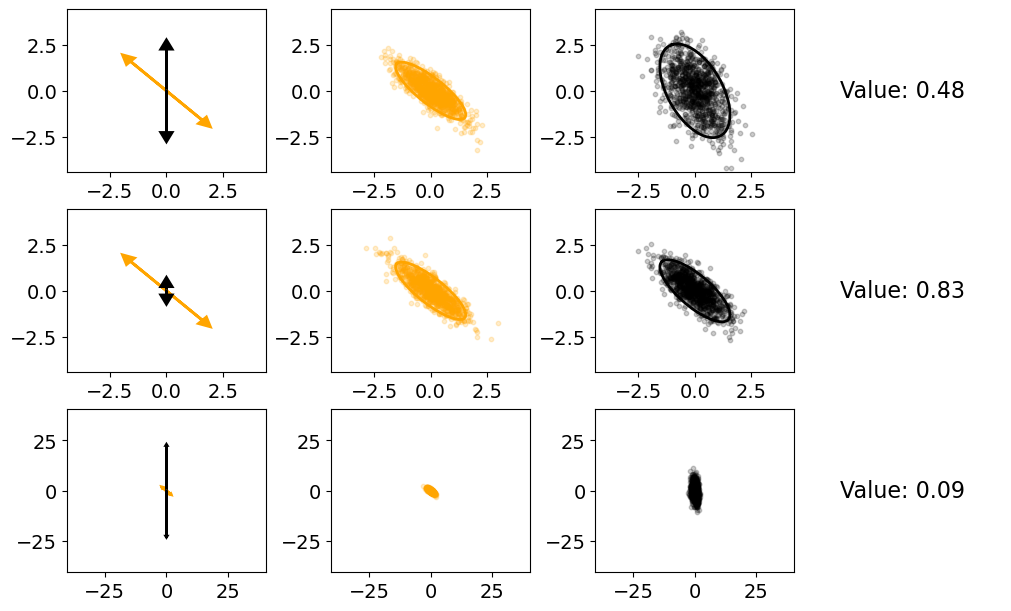

In [3]:
cfgs = [
    StimNuisance2D(
        name="equal_orthogonal",
        nuisance_direction=np.array([0.0, 1]),
        nuisance_amplitude=1.0,
    ),
    StimNuisance2D(
        name="tiny_orthogonal",
        nuisance_direction=np.array([0.0, 1]),
        nuisance_amplitude=0.1,
    ),
    StimNuisance2D(
        name="big_orthogonal",
        nuisance_direction=np.array([0.0, 1]),
        nuisance_amplitude=10.0,
    ),
]

fig, ax = plt.subplots(3, 4, figsize=(10, 6), layout="constrained")
for i, cfg in enumerate(cfgs):
    plot_stim_nuisance_2D(
        cfg,
        ax[i],
        extend_arrow_factor=2.25,
        linewidth=2.0,
        point_alpha=0.2,
        max_lim_factor=4,
    )

plt.show()

# Nuisance Dimensionality Study
Compare effects of nuisance dimensionality in three different cases for the three measurements

In [122]:
# For a given num_stim/dim_stim/nuisance_scale, let's observe how the SVR, SER, and CKA change as we increase nuisance dimensions
# - do this for orthogonal vs random (and for multiple iterations of each)
# - then we can also do this for different nuisance scale levels
# - (also do it for different alphas...)

# Global Config Parameters
num_neurons = 100
num_stimuli = 40
stim_dim = 25
alpha_stim = 1.0
alpha_nuisance = 1.0
noise_scale = 0.0
nuisance_angle = 0.0  # not used since we're not doing "angle" alignment, but here for future use

# Variable parameters
nuisance_dims = np.arange(25)  # shared across each "group"
nuisance_scale = 1.0
plot_groups = {
    "orthogonal": {"nuisance_alignment": "orthogonal"},
    "random": {"nuisance_alignment": "random"},
    "aligned": {"nuisance_alignment": "aligned"},
}

# Build configs for each group and nuisance dimension
configs: dict[str, list[StimFullConfig]] = defaultdict(list)
for group_name, group_params in plot_groups.items():
    for nuisance_dim in nuisance_dims:
        configs[group_name].append(
            StimFullConfig(
                num_neurons=num_neurons,
                num_stimuli=num_stimuli,
                stim_dim=stim_dim,
                nuisance_dim=nuisance_dim,
                alpha_stim=alpha_stim,
                alpha_nuisance=alpha_nuisance,
                nuisance_scale=nuisance_scale,
                nuisance_angle=nuisance_angle,
                noise_scale=noise_scale,
                **group_params,
            )
        )

# Now gather results
num_simulations = 10
num_samples = 2000
dtype = np.float64

results: dict[str, dict[str, np.ndarray]] = defaultdict(list)
for group_name, group_configs in configs.items():
    # Prepare the full array to hold results for this config group
    # It'll be a dict of measurement name -> array of shape (num_simulations, len(nuisance_dims))
    cfg_results: dict[str, np.ndarray] = defaultdict(lambda: np.full((num_simulations, len(nuisance_dims)), np.nan))

    # Go through each nuisance dim (list over group_configs)
    for idim, cfg in enumerate(tqdm(group_configs, desc=f"Processing group {group_name}")):
        # Simulate multiple times
        for isim in tqdm(range(num_simulations), desc=f"... simulations", leave=False):
            _result = process(cfg, dtype=dtype, num_samples=num_samples)

            # Scalar measurements
            popsvr = _result.population.kappa.ratio
            empsvr = _result.empirical.kappa.ratio
            popcka = _result.population.geometry.cka
            empcka = _result.empirical.diagnostics.cka
            cvempcka = _result.empirical.diagnostics.cv_cka
            trace_fraction = _result.population.geometry.trace_candidate / _result.population.geometry.trace_reference
            popser = _result.population.energy.ratio
            poprootser = _result.population.energy.as_variance_scale().ratio
            empser = _result.empirical.cv_energy.ratio
            emp_cvsvr = _result.empirical.cv_energy.as_variance_scale().ratio
            cv_popsvr = _result.empirical.cv_kappa.ratio

            cfg_results["Population SVR"][isim, idim] = popsvr
            cfg_results["Empirical SVR"][isim, idim] = empsvr
            cfg_results["Population CKA"][isim, idim] = popcka
            cfg_results["Empirical CKA"][isim, idim] = empcka
            cfg_results["Empirical cvCKA"][isim, idim] = cvempcka
            cfg_results["tr(Stim)/tr(Full)"][isim, idim] = trace_fraction
            cfg_results["Population SER"][isim, idim] = popser
            cfg_results["Population rootSER"][isim, idim] = poprootser
            cfg_results["Empirical cvSER"][isim, idim] = empser
            cfg_results["Empirical cvSVR"][isim, idim] = emp_cvsvr
            cfg_results["Empirical cvKappa SVR"][isim, idim] = cv_popsvr

    # Save results to group
    results[group_name] = cfg_results

Processing group aligned: 100%|██████████| 25/25 [00:25<00:00,  1.01s/it]


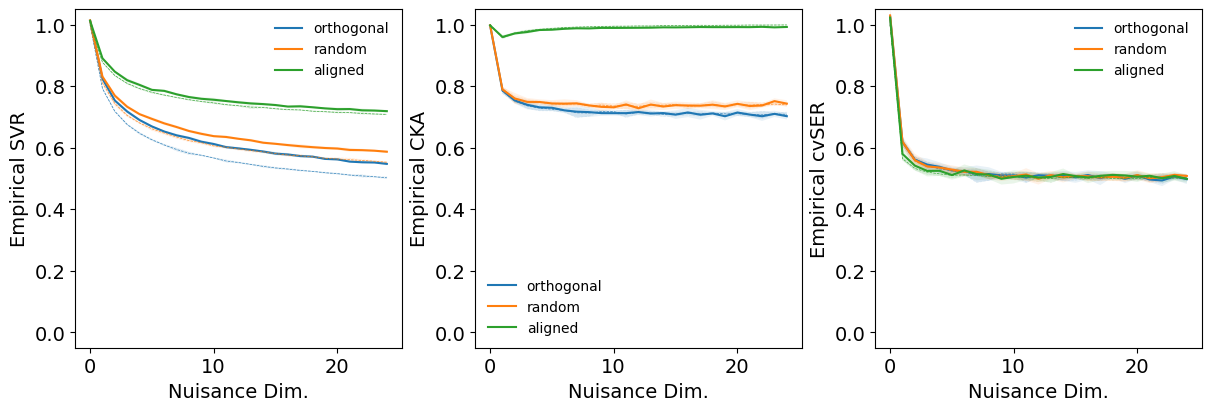

In [137]:
cv_empirical_kappa = False
cvcka = False
cv_var_scale = False
show = "both"
if show == "empirical":
    axes = [
        "Empirical cvKappa SVR" if cv_empirical_kappa else "Empirical SVR",
        "Empirical cvCKA" if cvcka else "Empirical CKA",
        "Empirical cvSVR" if cv_var_scale else "Empirical cvSER",
    ]
    _axes = None
elif show == "population":
    axes = [
        "Population SVR",
        "Population CKA",
        "Population rootSER" if cv_var_scale else "Population SER",
    ]
    _axes = None
elif show == "both":
    axes = [
        "Empirical cvKappa SVR" if cv_empirical_kappa else "Empirical SVR",
        "Empirical cvCKA" if cvcka else "Empirical CKA",
        "Empirical cvSVR" if cv_var_scale else "Empirical cvSER",
    ]
    _axes = [
        "Population SVR",
        "Population CKA",
        "Population rootSER" if cv_var_scale else "Population SER",
    ]

colors = plt.colormaps["tab10"].colors[: len(results)]
plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for igroup, group_name in enumerate(results):
    _results = results[group_name]
    for imeasure, measure_name in enumerate(axes):
        data = _results[measure_name]
        errorPlot(nuisance_dims, data, ax=ax[imeasure], label=group_name, axis=0, alpha=0.1)
        ax[imeasure].set_xlabel("Nuisance Dim.")
        ax[imeasure].set_ylabel(measure_name)
        ax[imeasure].legend(loc="best", fontsize=10, frameon=False)
        ax[imeasure].set_ylim(-0.05, 1.05)
        if _axes is not None:
            _pop_data = _results[_axes[imeasure]]
            errorPlot(
                nuisance_dims,
                _pop_data,
                ax=ax[imeasure],
                color=(colors[igroup], 0.9),
                axis=0,
                alpha=0.1,
                linestyle="--",
                linewidth=0.5,
            )

plt.show()

# Nuisance Scale Study
Compare effects of nuisance_scale in three different cases for the three measurements

In [113]:
# For a given num_stim/dim_stim/nuisance_scale, let's observe how the SVR, SER, and CKA change as we increase nuisance dimensions
# - do this for orthogonal vs random (and for multiple iterations of each)
# - then we can also do this for different nuisance scale levels
# - (also do it for different alphas...)

# Global Config Parameters
num_neurons = 100
num_stimuli = 40
stim_dim = 25
nuisance_dims = 10
alpha_stim = 1.0
alpha_nuisance = 1.0
nuisance_angle = 0.0  # not used since we're not doing "angle" alignment, but here for future use
noise_scale = 0.0

# Variable parameters
nuisance_scale_values = np.logspace(-2, 2, 21)
plot_groups = {
    "orthogonal": {"nuisance_alignment": "orthogonal"},
    "random": {"nuisance_alignment": "random"},
    "aligned": {"nuisance_alignment": "aligned"},
}

# Build configs for each group and nuisance dimension
configs: dict[str, list[StimFullConfig]] = defaultdict(list)
for group_name, group_params in plot_groups.items():
    for nuisance_scale in nuisance_scale_values:
        configs[group_name].append(
            StimFullConfig(
                num_neurons=num_neurons,
                num_stimuli=num_stimuli,
                stim_dim=stim_dim,
                nuisance_dim=nuisance_dim,
                alpha_stim=alpha_stim,
                alpha_nuisance=alpha_nuisance,
                nuisance_scale=nuisance_scale,
                nuisance_angle=nuisance_angle,
                noise_scale=noise_scale,
                **group_params,
            )
        )

# Now gather results
num_simulations = 10
num_samples = 2000
dtype = np.float64

results: dict[str, dict[str, np.ndarray]] = defaultdict(list)
for group_name, group_configs in configs.items():
    # Prepare the full array to hold results for this config group
    # It'll be a dict of measurement name -> array of shape (num_simulations, len(nuisance_scale_values))
    cfg_results: dict[str, np.ndarray] = defaultdict(lambda: np.full((num_simulations, len(nuisance_scale_values)), np.nan))

    # Go through each nuisance dim (list over group_configs)
    for idim, cfg in enumerate(tqdm(group_configs, desc=f"Processing group {group_name}")):
        # Simulate multiple times
        for isim in tqdm(range(num_simulations), desc=f"... simulations", leave=False):
            _result = process(cfg, dtype=dtype, num_samples=num_samples)

            # Scalar measurements
            popsvr = _result.population.kappa.ratio
            empsvr = _result.empirical.kappa.ratio
            popcka = _result.population.geometry.cka
            empcka = _result.empirical.diagnostics.cka
            cvempcka = _result.empirical.diagnostics.cv_cka
            trace_fraction = _result.population.geometry.trace_candidate / _result.population.geometry.trace_reference
            popser = _result.population.energy.ratio
            empser = _result.empirical.cv_energy.ratio

            cfg_results["Population SVR"][isim, idim] = popsvr
            cfg_results["Empirical SVR"][isim, idim] = empsvr
            cfg_results["Population CKA"][isim, idim] = popcka
            cfg_results["Empirical CKA"][isim, idim] = empcka
            cfg_results["Empirical cvCKA"][isim, idim] = cvempcka
            cfg_results["tr(Stim)/tr(Full)"][isim, idim] = trace_fraction
            cfg_results["Population SER"][isim, idim] = popser
            cfg_results["Empirical cvSER"][isim, idim] = empser

    # Save results to group
    results[group_name] = cfg_results

Processing group orthogonal:  71%|███████▏  | 15/21 [00:06<00:02,  2.14it/s]C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\simulations\shared_variance.py:190: RuntimeWarning: invalid value encountered in sqrt
  denominator = np.sqrt(np.trace(A @ A) * np.trace(B @ B))
Processing group aligned: 100%|██████████| 21/21 [00:13<00:00,  1.55it/s]


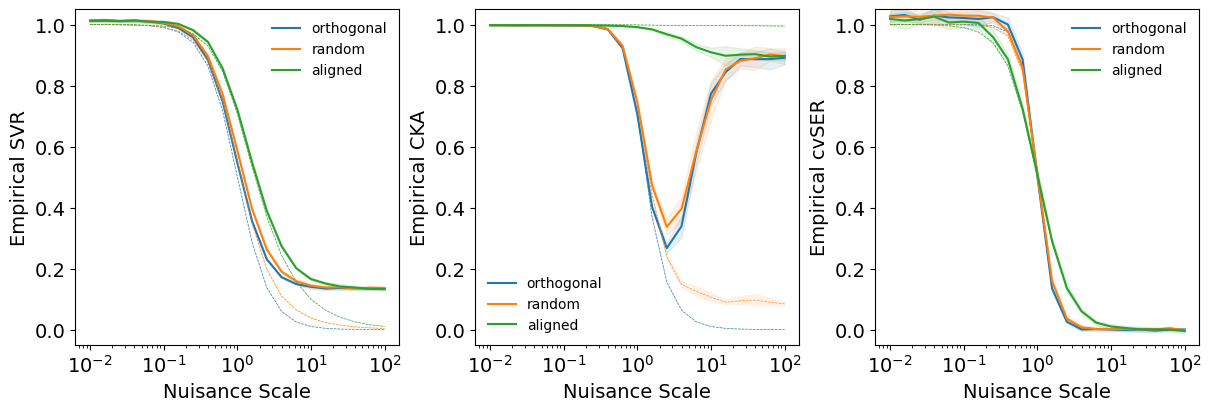

In [114]:
cvcka = False
show = "both"
if show == "empirical":
    axes = ["Empirical SVR", "Empirical cvCKA" if cvcka else "Empirical CKA", "Empirical cvSER"]
    _axes = None
elif show == "population":
    axes = ["Population SVR", "Population CKA", "Population SER"]
    _axes = None
elif show == "both":
    axes = ["Empirical SVR", "Empirical cvCKA" if cvcka else "Empirical CKA", "Empirical cvSER"]
    _axes = ["Population SVR", "Population CKA", "Population SER"]

colors = plt.colormaps["tab10"].colors[: len(results)]
plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for igroup, group_name in enumerate(results):
    _results = results[group_name]
    for imeasure, measure_name in enumerate(axes):
        data = _results[measure_name]
        errorPlot(nuisance_scale_values, data, ax=ax[imeasure], label=group_name, color=colors[igroup], axis=0, alpha=0.1)
        ax[imeasure].set_xlabel("Nuisance Scale")
        ax[imeasure].set_ylabel(measure_name)
        ax[imeasure].legend(loc="best", fontsize=10, frameon=False)
        ax[imeasure].set_xscale("log")
        ax[imeasure].set_ylim(-0.05, 1.05)
        if _axes is not None:
            _pop_data = _results[_axes[imeasure]]
            errorPlot(
                nuisance_scale_values,
                _pop_data,
                ax=ax[imeasure],
                color=(colors[igroup], 0.9),
                axis=0,
                alpha=0.1,
                linestyle="--",
                linewidth=0.5,
            )
plt.show()

# Noise Scale Study
Compare effects of noise_scale in three different cases for the three measurements

In [118]:
# For a given num_stim/dim_stim/nuisance_scale, let's observe how the SVR, SER, and CKA change as we increase nuisance dimensions
# - do this for orthogonal vs random (and for multiple iterations of each)
# - then we can also do this for different nuisance scale levels
# - (also do it for different alphas...)

# Global Config Parameters
num_neurons = 100
num_stimuli = 40
stim_dim = 25
nuisance_dims = 10
alpha_stim = 1.0
alpha_nuisance = 1.0
nuisance_scale = 1.0
nuisance_angle = 0.0  # not used since we're not doing "angle" alignment, but here for future use

# Variable parameters
noise_scale_values = np.logspace(-3, 1, 11)
plot_groups = {
    "orthogonal": {"nuisance_alignment": "orthogonal"},
    "random": {"nuisance_alignment": "random"},
    "aligned": {"nuisance_alignment": "aligned"},
}

# Build configs for each group and nuisance dimension
configs: dict[str, list[StimFullConfig]] = defaultdict(list)
for group_name, group_params in plot_groups.items():
    for noise_scale in noise_scale_values:
        configs[group_name].append(
            StimFullConfig(
                num_neurons=num_neurons,
                num_stimuli=num_stimuli,
                stim_dim=stim_dim,
                nuisance_dim=nuisance_dim,
                alpha_stim=alpha_stim,
                alpha_nuisance=alpha_nuisance,
                nuisance_scale=nuisance_scale,
                nuisance_angle=nuisance_angle,
                noise_scale=noise_scale,
                **group_params,
            )
        )

# Now gather results
num_simulations = 10
num_samples = 2000
dtype = np.float64

results: dict[str, dict[str, np.ndarray]] = defaultdict(list)
for group_name, group_configs in configs.items():
    # Prepare the full array to hold results for this config group
    # It'll be a dict of measurement name -> array of shape (num_simulations, len(noise_scale_values))
    cfg_results: dict[str, np.ndarray] = defaultdict(lambda: np.full((num_simulations, len(noise_scale_values)), np.nan))

    # Go through each nuisance dim (list over group_configs)
    for idim, cfg in enumerate(tqdm(group_configs, desc=f"Processing group {group_name}")):
        # Simulate multiple times
        for isim in tqdm(range(num_simulations), desc=f"... simulations", leave=False):
            _result = process(cfg, dtype=dtype, num_samples=num_samples)

            # Scalar measurements
            popsvr = _result.population.kappa.ratio
            empsvr = _result.empirical.kappa.ratio
            popcka = _result.population.geometry.cka
            empcka = _result.empirical.diagnostics.cka
            cvempcka = _result.empirical.diagnostics.cv_cka
            trace_fraction = _result.population.geometry.trace_candidate / _result.population.geometry.trace_reference
            popser = _result.population.energy.ratio
            empser = _result.empirical.cv_energy.ratio

            cfg_results["Population SVR"][isim, idim] = popsvr
            cfg_results["Empirical SVR"][isim, idim] = empsvr
            cfg_results["Population CKA"][isim, idim] = popcka
            cfg_results["Empirical CKA"][isim, idim] = empcka
            cfg_results["Empirical cvCKA"][isim, idim] = cvempcka
            cfg_results["tr(Stim)/tr(Full)"][isim, idim] = trace_fraction
            cfg_results["Population SER"][isim, idim] = popser
            cfg_results["Empirical cvSER"][isim, idim] = empser

    # Save results to group
    results[group_name] = cfg_results

Processing group aligned: 100%|██████████| 11/11 [00:04<00:00,  2.23it/s]


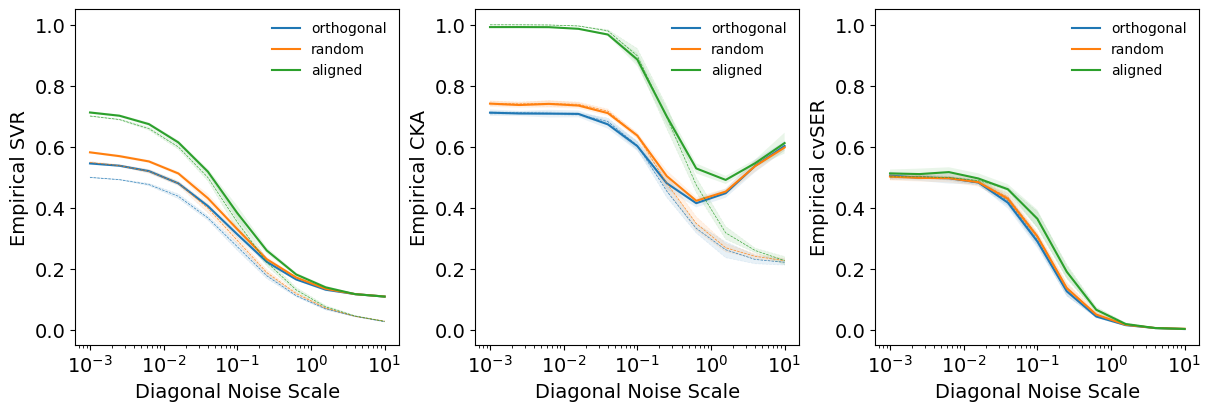

In [120]:
cvcka = False
show = "both"
if show == "empirical":
    axes = ["Empirical SVR", "Empirical cvCKA" if cvcka else "Empirical CKA", "Empirical cvSER"]
    _axes = None
elif show == "population":
    axes = ["Population SVR", "Population CKA", "Population SER"]
    _axes = None
elif show == "both":
    axes = ["Empirical SVR", "Empirical cvCKA" if cvcka else "Empirical CKA", "Empirical cvSER"]
    _axes = ["Population SVR", "Population CKA", "Population SER"]

plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for igroup, group_name in enumerate(results):
    _results = results[group_name]
    for imeasure, measure_name in enumerate(axes):
        data = _results[measure_name]
        errorPlot(noise_scale_values, data, ax=ax[imeasure], label=group_name, axis=0, alpha=0.1)
        ax[imeasure].set_xlabel("Diagonal Noise Scale")
        ax[imeasure].set_ylabel(measure_name)
        ax[imeasure].legend(loc="best", fontsize=10, frameon=False)
        ax[imeasure].set_xscale("log")
        ax[imeasure].set_ylim(-0.05, 1.05)
        if _axes is not None:
            _pop_data = _results[_axes[imeasure]]
            errorPlot(
                noise_scale_values,
                _pop_data,
                ax=ax[imeasure],
                color=(colors[igroup], 0.9),
                axis=0,
                alpha=0.1,
                linestyle="--",
                linewidth=0.5,
            )

plt.show()

# 2D SVR Schematics
Sweep nuisance **angle** or **amplitude** in 2D to illustrate how SVR depends on alignment and scale.

In [ ]:
from dimensionality_manuscript.schematics.subspace import StimNuisanceArray2D, plot_stim_nuisance_array_2D

In [ ]:
# Angle sweep: nuisance direction rotates 0 → π, amplitude fixed
cfg_angle = StimNuisanceArray2D(
    stim_direction=np.array([1.0, 0.0]),
    vary_type="angle",
    stim_amplitude=1.0,
    stim_orth_amplitude=0.1,
    nuisance_amplitude=0.5,
    nuisance_orth_amplitude=0.05,
    noise_amplitude=0.1,
    n_nuisance=12,
    n_samples=500,
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), layout="constrained")
plot_stim_nuisance_array_2D(cfg_angle, tuple(axes), cmap_name="hsv", example_nuisance_idx=3)
axes[0].set_title("Stim distribution")
axes[1].set_title("Example nuisance")
axes[2].set_title("Schematic")
axes[3].set_title("SVR vs nuisance angle")
plt.show()

In [ ]:
# Amplitude sweep: nuisance direction fixed at 45°, amplitude scales 0 → 2
cfg_amp = StimNuisanceArray2D(
    stim_direction=np.array([1.0, 0.0]),
    vary_type="amplitude",
    stim_amplitude=1.0,
    stim_orth_amplitude=0.1,
    min_nuisance_amplitude=0.0,
    max_nuisance_amplitude=2.0,
    nuisance_angle=np.pi / 4,
    nuisance_orth_amplitude=0.05,
    noise_amplitude=0.1,
    n_nuisance=10,
    n_samples=500,
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), layout="constrained")
plot_stim_nuisance_array_2D(cfg_amp, tuple(axes), cmap_name="viridis", example_nuisance_idx=5)
axes[0].set_title("Stim distribution")
axes[1].set_title("Example nuisance")
axes[2].set_title("Schematic")
axes[3].set_title("SVR vs nuisance amplitude")
plt.show()